# Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, classification_report
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, average_precision_score, f1_score, log_loss
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif


In [60]:
pd.set_option("display.max_columns", None)


# Load data

In [61]:
bank_df = pd.read_csv("bank-marketing-dataset-full.csv", sep=";")
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [62]:
samples, features = bank_df.shape
print(f"The dataset contains {samples} sampled and {features} features ")

The dataset contains 41188 sampled and 21 features 


In [63]:
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# EDA
- Check missing values
- Understand feature ranges and distribution
- Examin pairwise correlation

In [64]:
bank_df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

There are no Missing data, however missing data are labeled as "unknown"

In [65]:
print(f"'unknown' in each features")
missing = []
for col in bank_df.columns:
    unknown_count = bank_df[bank_df[col] == 'unknown'][col].value_counts()
    if unknown_count.values.size>0:
        missing.append({"Feature": col, "feature_type": bank_df[col].dtypes, "ncount": unknown_count.values[0], "percentage": round((unknown_count.values[0]/samples)*100, 2)})
        #print(f"feature: {col}, feature_type: {bank_df[col].dtypes}: \ncount: {unknown_count.values[0]}, percentage: {round((unknown_count.values[0]/samples)*100, 2)}%")
missing_df = pd.DataFrame(missing)
missing_df.sort_values(by="percentage", ascending=False)



'unknown' in each features


,Feature,feature_type,ncount,percentage
3,default,object,8597,20.87
2,education,object,1731,4.20
4,housing,object,990,2.40
5,loan,object,990,2.40
0,job,object,330,0.80
1,marital,object,80,0.19


Unknown percentage is less than 50%, so descided not to drop the feature, instead will impute with appropriate data.

In [66]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [67]:
bank_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [68]:
#No of duplicate row
print(f"No of duplicated rows: {bank_df.duplicated().sum()}")

No of duplicated rows: 12


In [69]:
# drop duplicates:

bank_df.drop_duplicates(inplace=True)
bank_df.shape

(41176, 21)

In [70]:
bank_df["y"] = bank_df["y"].map({'yes': 1, 'no':0})

In [71]:
object_cols = bank_df.select_dtypes("object").columns.to_list()
number_cols = bank_df.select_dtypes(["int64", "float64"]).columns.to_list()

print(f"Object Columns: {object_cols}")
print(f"Numeric Columns: {number_cols}")
print(f"Number of object columns: {len(object_cols)}, number of number columns: {len(number_cols)}")

Object Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Number of object columns: 10, number of number columns: 11


### Distribution of numeric features

In [72]:
def numeric_distribution_plot(df, target):
    fig, axes = plt.subplots(11,2, figsize = (16,50))

    for i, col in enumerate(df.columns.to_list()):
        feature_mean = df[col].mean()
        feature_median = df[col].median()

        sns.histplot(df, x= col, hue=target,  ax=axes[i][0])
        axes[i][0].axvline(feature_mean, color='red', linestyle='--', label=f"Mean: {feature_mean}")
        axes[i][0].axvline(feature_median, color='green', linestyle='-', label=f"Median: {feature_median}")
        axes[i][0].set_title(f"'{col}' feature Distribution")
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel("Frequency")
        axes[i][0].legend()

        #sns.boxplot(df[col], ax=axes[i][1])

        sns.boxplot(data=df, x=target, y=col, ax=axes[i][1])
        
        axes[i][1].set_title(f"Boxplot of '{col}'")
        #axes[i][1].set_xlabel(col)


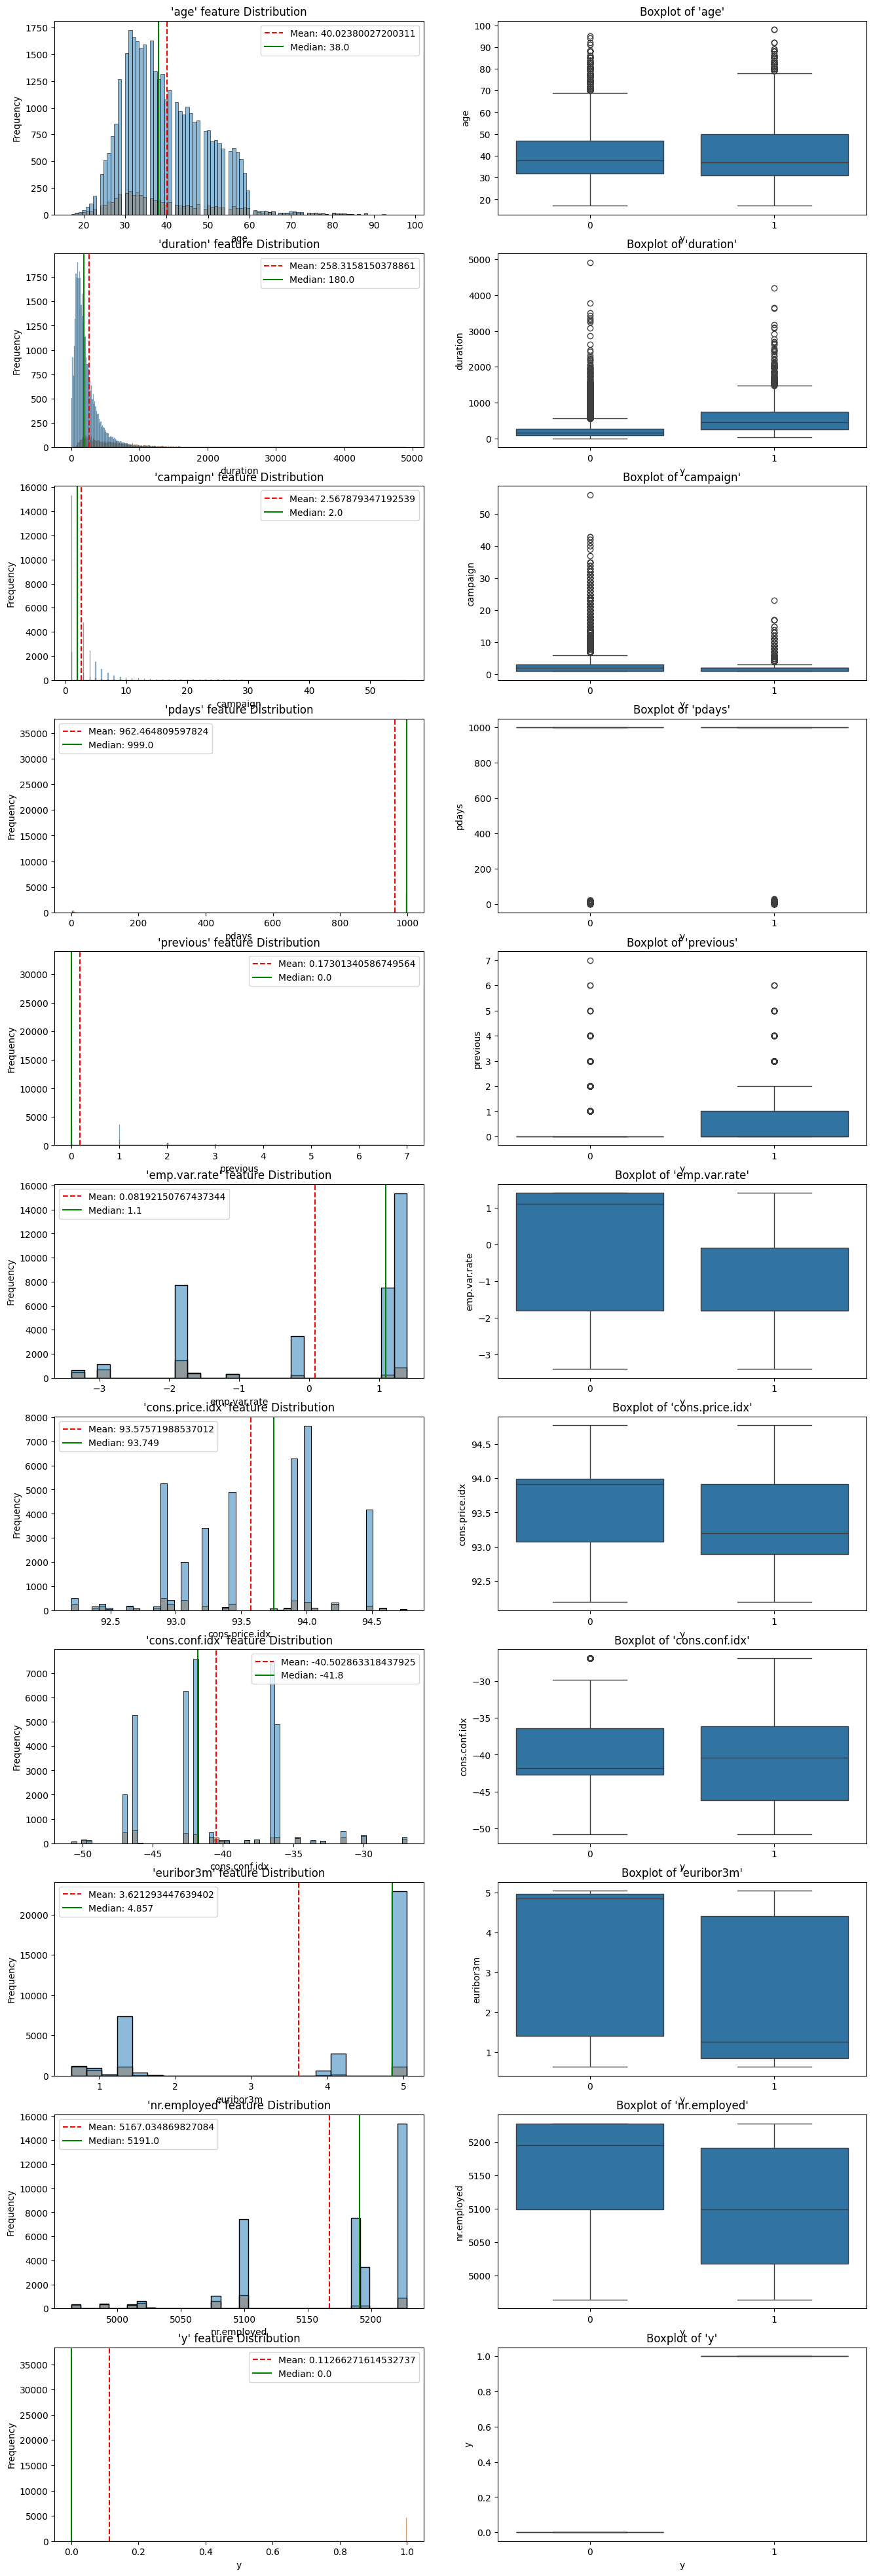

In [73]:
numeric_distribution_plot(bank_df[number_cols], bank_df['y'])

In [74]:
bank_df.groupby("emp.var.rate")["y"].value_counts(normalize=True)

emp.var.rate  y
-3.4          0    0.575701
              1    0.424299
-3.0          1    0.511628
              0    0.488372
-2.9          0    0.643201
              1    0.356799
-1.8          0    0.840884
              1    0.159116
-1.7          1    0.521345
              0    0.478655
-1.1          0    0.525984
              1    0.474016
-0.2          0    0.900000
              1    0.100000
-0.1          0    0.936991
              1    0.063009
 1.1          0    0.969080
              1    0.030920
 1.4          0    0.946635
              1    0.053365
Name: proportion, dtype: float64

- lower emp.var.rate (Employment Variation Rate) means weak economy and positive means strong economy.
    From the above data it looks that when emp.var.rate is low, subscription rate is high. 
- cons.price.idx (Inflation) - low tends to subscribe more
- cons.conf.idx - consumer confidence index - almost same
- euribor3m - 3 months interest rate - low euribor3m more subscription
- nr.employed - overall employment level in the economy - lower employment higher subscription

In [75]:
# # skewness

# from statistics import quantiles

# numeric_cols = ['age', 'duration', 'campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
# # 'pdays', 'previous',

# for col in numeric_cols:
#     q1, q2, q3 = quantiles(bank_df[col])
#     skb = (q1+q3-2*q2) / (q3 - q1)
#     print(f"{col}: {round(skb, 3)}")
#     if abs(skb) > 0.5:
#         print(f"{col} is skewed\n")
#     else:
#         print(f"{col} is symmetric\n")

Skewness: 
Highly skewed : 'emp.var.rate', cons.conf.idx', 'euribor3m',
Symmetric: 'age', 'duration', 'campaign', 'cons.price.idx', 'nr.employed'

If customer is never contacted then ‘Pdays’ is marked as 999 and ‘previous’ as 0. Create a new boolean feature __was_customer_contact__ (yes/no) to better specify this situation.

In [76]:
# Column 'pdays' - 96% of the data is 999(not contacted)
bank_df["was_contacted_before"] = (bank_df["pdays"] == 999).astype('int')
#bank_df.drop(columns=["pdays"], inplace=True)
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1


### Outlier counts

In [77]:
numeric_cols = [col for col in number_cols if col != 'y']
# 

def count_outliers(col):
    q1, q3 = col.quantile([0.25, 0.75])
    iqr = q3-q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((col<lower) | (col > upper)).mean()

outlier_df = (bank_df[numeric_cols]\
            .apply(count_outliers)).reset_index()\
            .rename(columns={"index": "Feature", 0: "Percentage"})\
            .sort_values(by="Percentage", ascending=False)

outlier_df

,Feature,Percentage
4,previous,0.136609
1,duration,0.071959
2,campaign,0.058432
3,pdays,0.036793
0,age,0.011366
7,cons.conf.idx,0.010832
5,emp.var.rate,0.000000
6,cons.price.idx,0.000000
8,euribor3m,0.000000
9,nr.employed,0.000000


In [78]:
# for col in number_cols:
#     plt.figure(figsize=(5,4))
#     sns.boxplot(data=bank_df[number_cols], x="y", y=col)
#     plt.title(f"{col} vs Target")
#     plt.show()

### Distribution of categorical features

In [79]:
def object_distribution_plot(df):
    fig, axes = plt.subplots(6,2, figsize = (24,30))
    axes = axes.flatten()

    for i, col in enumerate(df.columns.to_list()):
        count = df[col].value_counts()
        
        axes[i].bar(count.index, count.values)
        #axes[i].bar_label(axes[i].containers[0], fontsize=10)
        
        total = sum(count.values)
        for container in axes[i].containers:
            labels = [f"{(h/total)*100: .1f}%" for h in container.datavalues]
            axes[i].bar_label(container, labels=labels, fontsize=10)
        
        axes[i].set_title(f"'{col}' feature Distribution")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(len(df.columns.to_list()), len(axes)):
        axes[j].set_visible(False)

In [80]:
target = ["y"]
#object_distribution_plot(bank_df[object_cols+target])

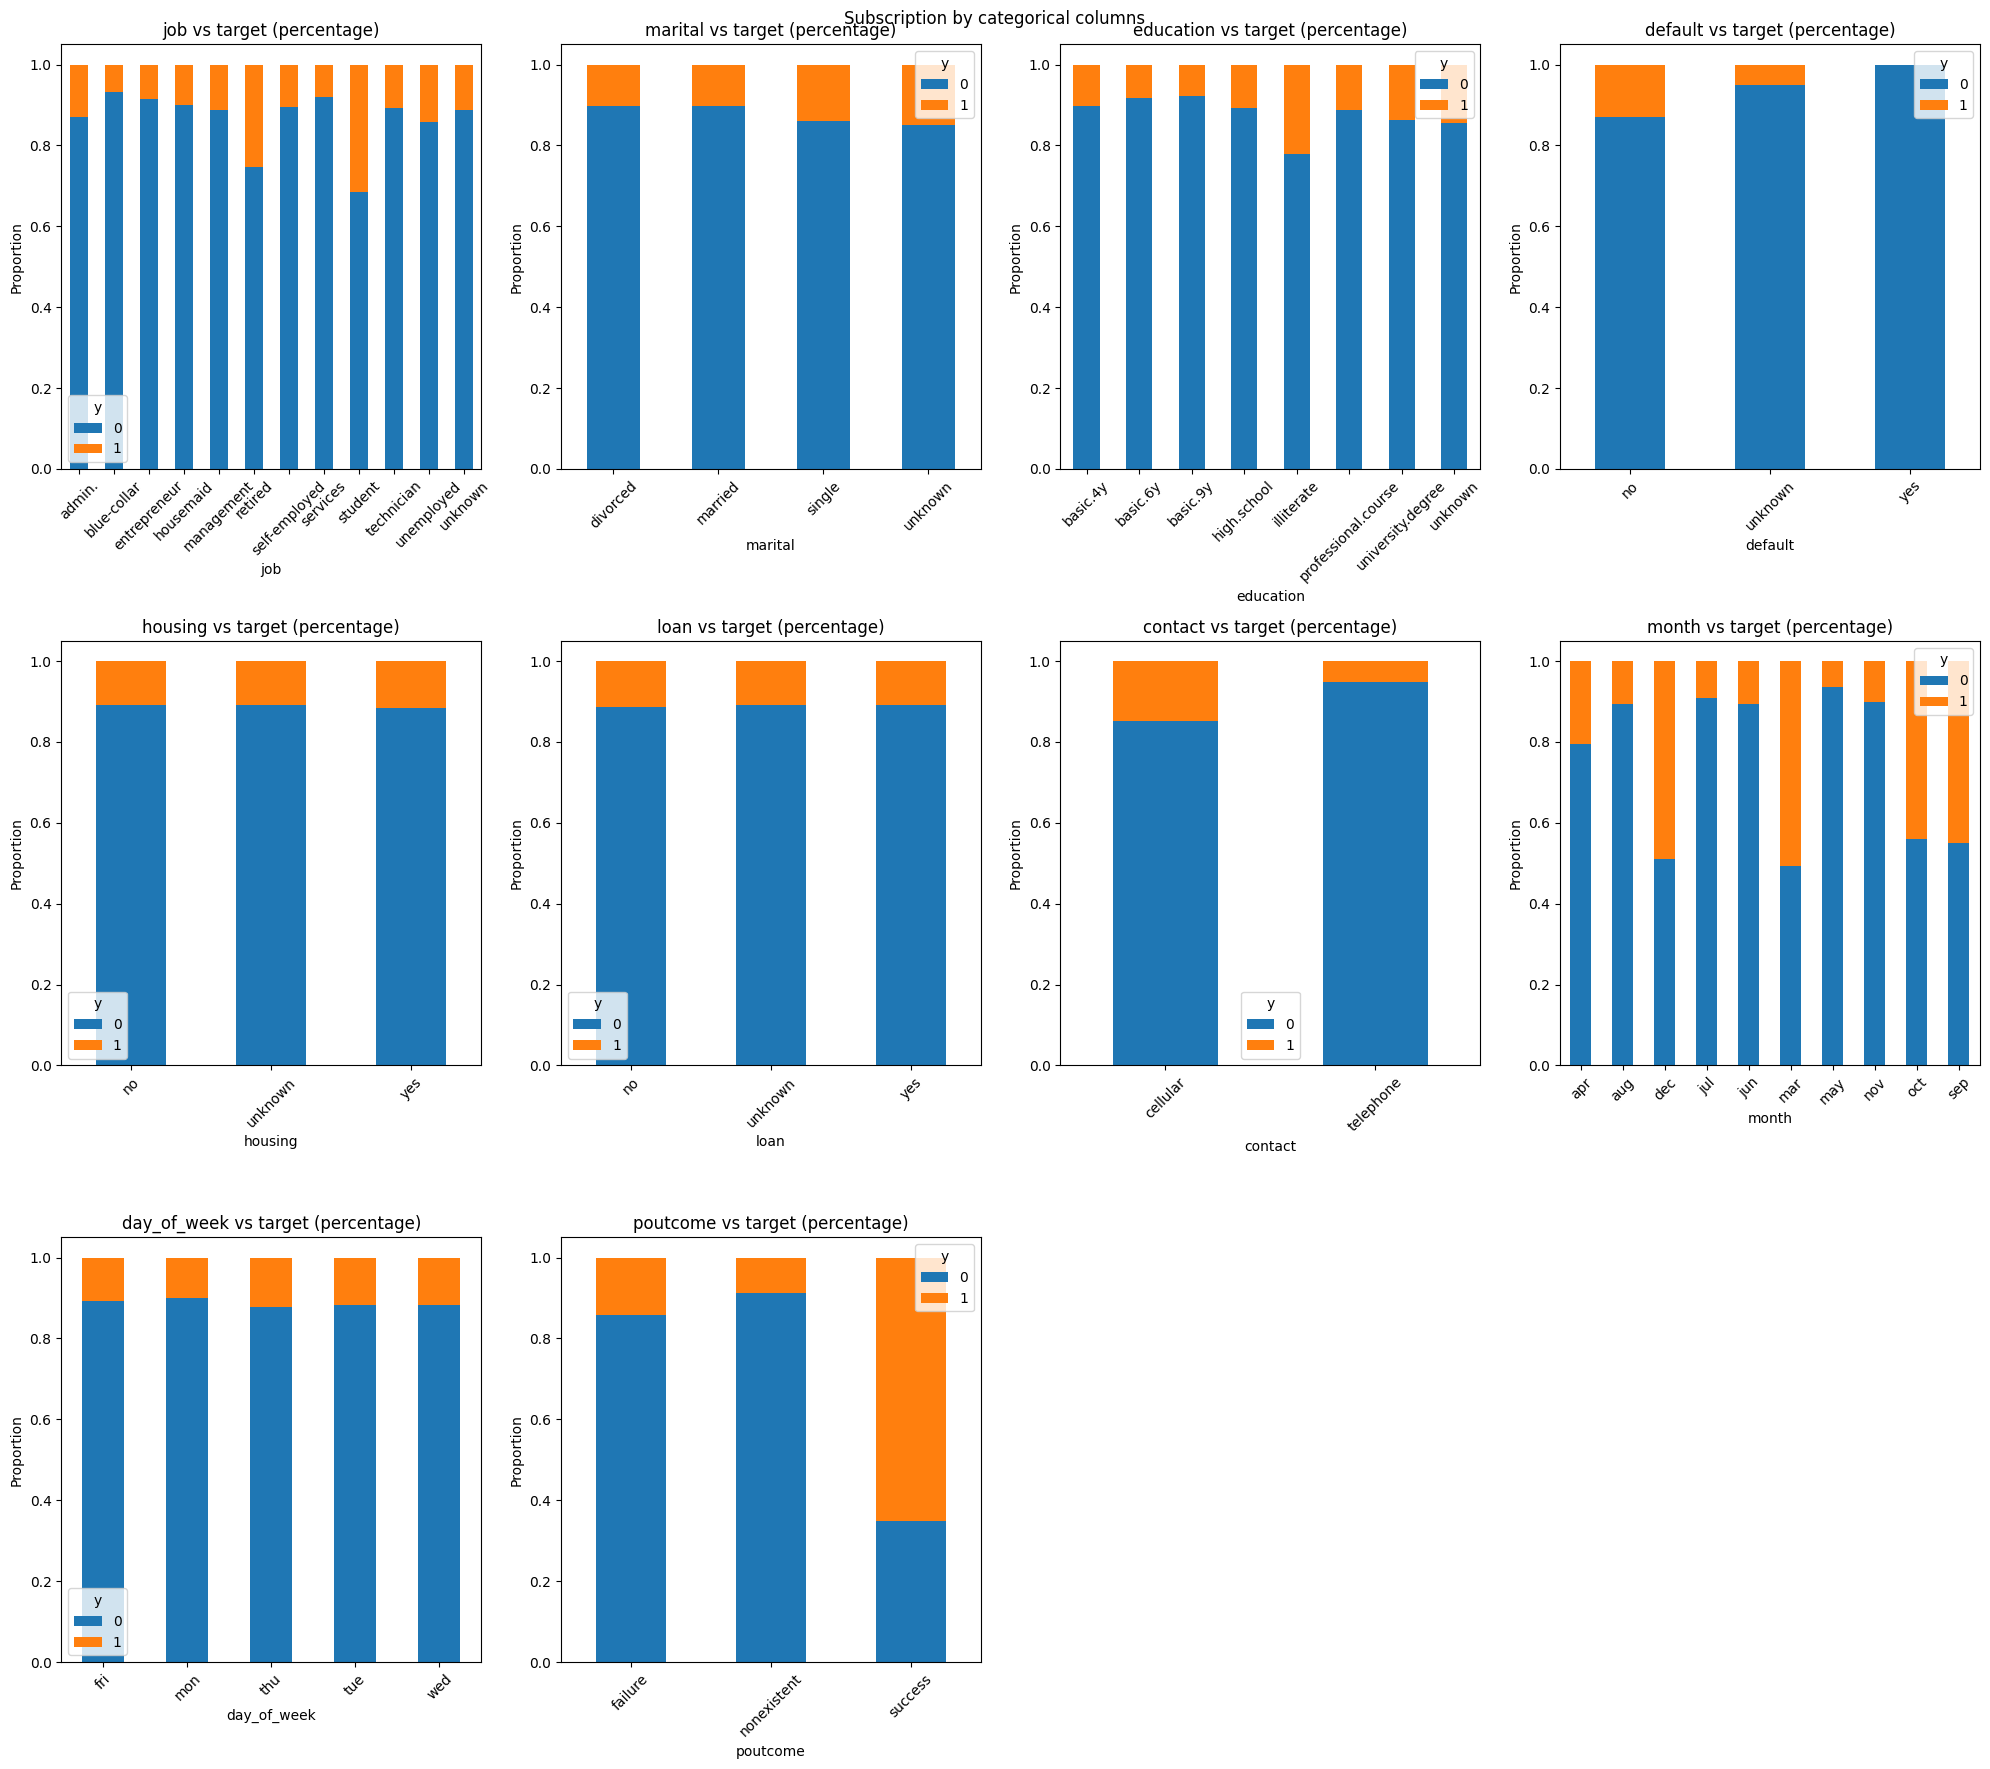

In [81]:
fig, axes = plt.subplots(3,4, figsize = (20,18))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    ct = pd.crosstab(bank_df[col], bank_df['y'], normalize='index')

    ct.plot(kind='bar', stacked=True, ax = axes[i])
    axes[i].set_title(f"{col} vs target (percentage)")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis ='x', rotation=45)

for j in range(len(object_cols), len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle("Subscription by categorical columns")
plt.tight_layout()
plt.show()

<Axes: xlabel='job'>

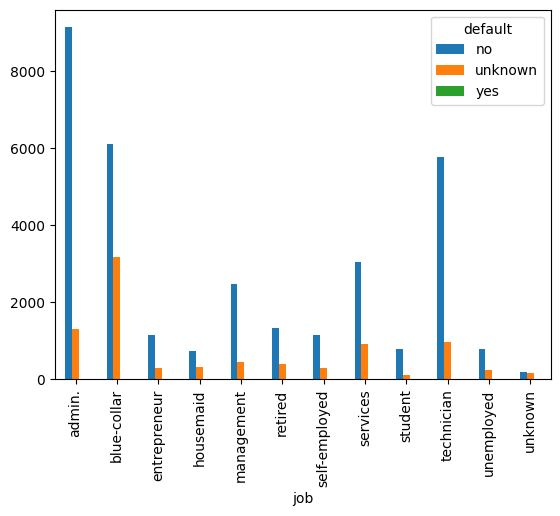

In [82]:
ct = bank_df.groupby(["job", "default"])["y"].count()
ct_unstacked = ct.unstack()
ct_unstacked.plot(kind='bar')


Target Distribution is imbalance.

### Bivariate analysis

In [83]:
#sns.pairplot(bank_df[number_cols], hue="y")

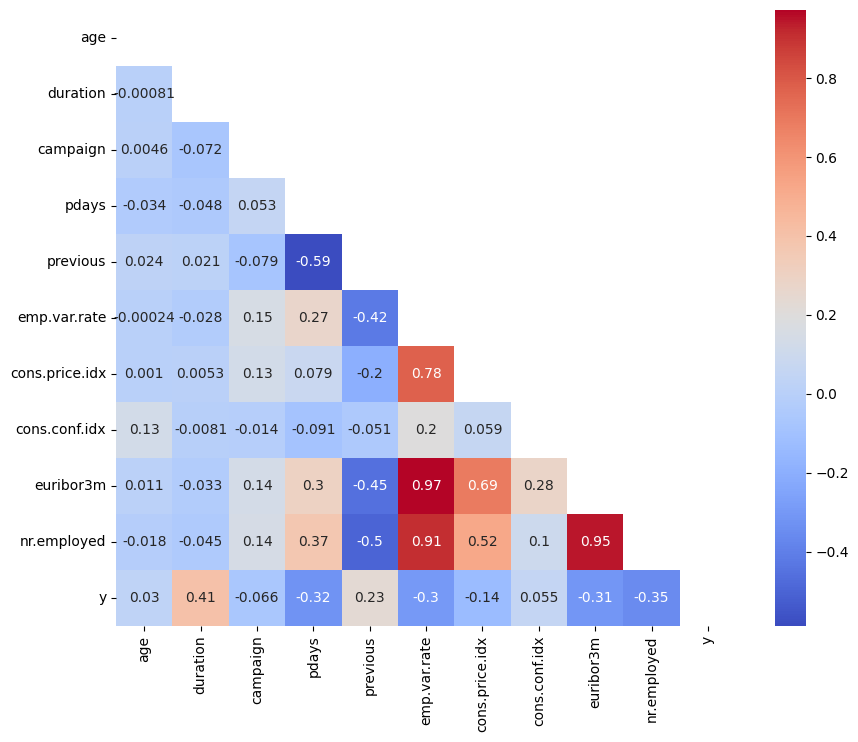

In [84]:
corr = bank_df[number_cols].corr()
plt.figure(figsize=(10,8))

mask = np.triu(np.ones_like(corr, dtype=bool))  
sns.heatmap(corr, mask= mask, cmap='coolwarm', annot=True)
plt.show()


# Hypothesis testing



### Welch's t-test Numerical columns

check if mean of the numerical variables differs significantly between subscription 'yes' and 'no' 

H0: The mean of the variable is same for subscribed and not subscribed customers.

Ha: The mean of the variable is not same for subscribed and not subscribed customers.

In [85]:
from scipy import  stats

alpha = 0.05

numeric_cols = ['age', 'duration', 'campaign', 'was_contacted_before', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

subscribed = bank_df[bank_df["y"] == 1]
not_subscribed = bank_df[bank_df["y"] == 0]

ttest_results = []

for col in numeric_cols:
    grouped_subscribed = subscribed[subscribed[col] != 'unknown'][col]
    grouped_not_subscribed = not_subscribed[not_subscribed[col] != 'unknown'][col]

    t_stat, p_value = stats.ttest_ind(grouped_subscribed, grouped_not_subscribed, equal_var=False)
    ttest_results.append({
        "col": col,
        "subscribed mean": round(grouped_subscribed.mean(),2),
        "Not subscribed mean": round(grouped_not_subscribed.mean(),2),
        "t_stat": round(t_stat, 4),
        "p_value": round(p_value, 8),
        "Reject H0": 'yes' if p_value < alpha else "No"
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,col,subscribed mean,Not subscribed mean,t_stat,p_value,Reject H0
0,age,40.91,39.91,4.7753,0.000002,yes
1,duration,553.26,220.87,55.4984,0.000000,yes
2,campaign,2.05,2.63,-20.2479,0.000000,yes
3,was_contacted_before,0.79,0.99,-32.2510,0.000000,yes
4,previous,0.49,0.13,28.1256,0.000000,yes
5,emp.var.rate,-1.23,0.25,-59.1166,0.000000,yes
6,cons.price.idx,93.35,93.60,-24.0670,0.000000,yes
7,cons.conf.idx,-39.79,-40.59,8.6227,0.000000,yes
8,euribor3m,2.12,3.81,-62.5603,0.000000,yes
9,nr.employed,5095.12,5176.17,-60.9589,0.000000,yes


T-test hypothesis testing on numerical features shows that there is significant difference in the mean of each feature between subscribed and not subscribed consumers.


### Chi-test for categorical columns
- H0: The categorical variable and subscription are independent
- H1: The categorical variable and subscription are not independent

In [86]:
from scipy import stats


alpha = 0.05

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


chi_test_results = []

for col in categorical_cols:
    #bank_df_subset = bank_df[bank_df[col] != 'unknown']
    contingency_table = pd.crosstab(bank_df[col], bank_df["y"])

    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    chi_test_results.append({
        "col": col,
        "chi-square Statistics": round(chi2, 4),
        "degree of freedom": dof,
        "p_value": round(p_value, 8),
        "Reject H0": 'yes' if p_value < alpha else "No"
    })

chi_test_results_df = pd.DataFrame(chi_test_results)
chi_test_results_df


,col,chi-square Statistics,degree of freedom,p_value,Reject H0
0,job,961.7438,11,0.000000,yes
1,marital,122.9593,3,0.000000,yes
2,education,192.8485,7,0.000000,yes
3,default,406.5561,2,0.000000,yes
4,housing,5.7422,2,0.056638,No
5,loan,1.0993,2,0.577153,No
6,contact,862.0807,1,0.000000,yes
7,month,3103.0327,9,0.000000,yes
8,day_of_week,26.0542,4,0.000031,yes
9,poutcome,4230.1434,2,0.000000,yes


Chi-test on categorical features shows subscription oucome strongly dependent on 'job', 'marital', 'education', 'default','contact', 'month', 'day_of_week', 'poutcome' features.

y is not depenedent on Housing and loan

In [87]:
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1


# Feature Selection

## Train test split

In [88]:
X = bank_df.drop("y", axis=1)
y = bank_df["y"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=9)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32940, 21), (8236, 21), (32940,), (8236,))

In [89]:
df = pd.DataFrame({})
y_train.value_counts(normalize=True)

y
0    0.887341
1    0.112659
Name: proportion, dtype: float64

In [90]:
y_test.value_counts(normalize=True)

y
0    0.887324
1    0.112676
Name: proportion, dtype: float64

In [91]:
X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before
167,56,admin.,divorced,unknown,unknown,no,no,telephone,may,mon,114,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,1
19594,29,services,single,professional.course,no,yes,yes,cellular,aug,thu,99,3,999,0,nonexistent,1.4,93.444,-36.1,4.968,5228.1,1
10286,40,blue-collar,married,unknown,unknown,yes,no,telephone,jun,mon,69,2,999,0,nonexistent,1.4,94.465,-41.8,4.960,5228.1,1
40858,59,unemployed,married,basic.9y,no,yes,yes,cellular,oct,fri,142,1,999,0,nonexistent,-1.1,94.601,-49.5,0.942,4963.6,1
34798,35,services,married,high.school,no,yes,no,cellular,may,thu,223,2,999,0,nonexistent,-1.8,92.893,-46.2,1.266,5099.1,1


In [92]:
numeric_cols_standard_fs = ['age', 'duration','campaign','previous','pdays','emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed','was_contacted_before','cons.conf.idx']
#numeric_cols_robust_fs = ['age', 'duration','campaign','previous'] # features with outliers

object_cols_fs = X_train.select_dtypes(include='object').columns.to_list()

preprocessor_fs = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), numeric_cols_standard_fs),
    #('robust', RobustScaler(), numeric_cols_robust_fs),
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore'), object_cols_fs)
])

X_train_encoded = preprocessor_fs.fit_transform(X_train)
X_test_encoded = preprocessor_fs.transform(X_test)

In [93]:
def extract_feature_names(feature_names: list)->list:
    unique_features = set([feature.split("__")[1].split("_")[0] for feature in feature_names])
    return unique_features

## Variance Threshold

/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


Variance Threshold - > Kept features: 19
count: 38, {'marital', 'was', 'nr.employed', 'cons.conf.idx', 'poutcome', 'housing', 'campaign', 'previous', 'emp.var.rate', 'age', 'month', 'contact', 'euribor3m', 'default', 'duration', 'education', 'loan', 'pdays', 'job', 'cons.price.idx', 'day'}


/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Text(0.5, 1.0, 'Feature Variance - Threshold > 0.1 ')

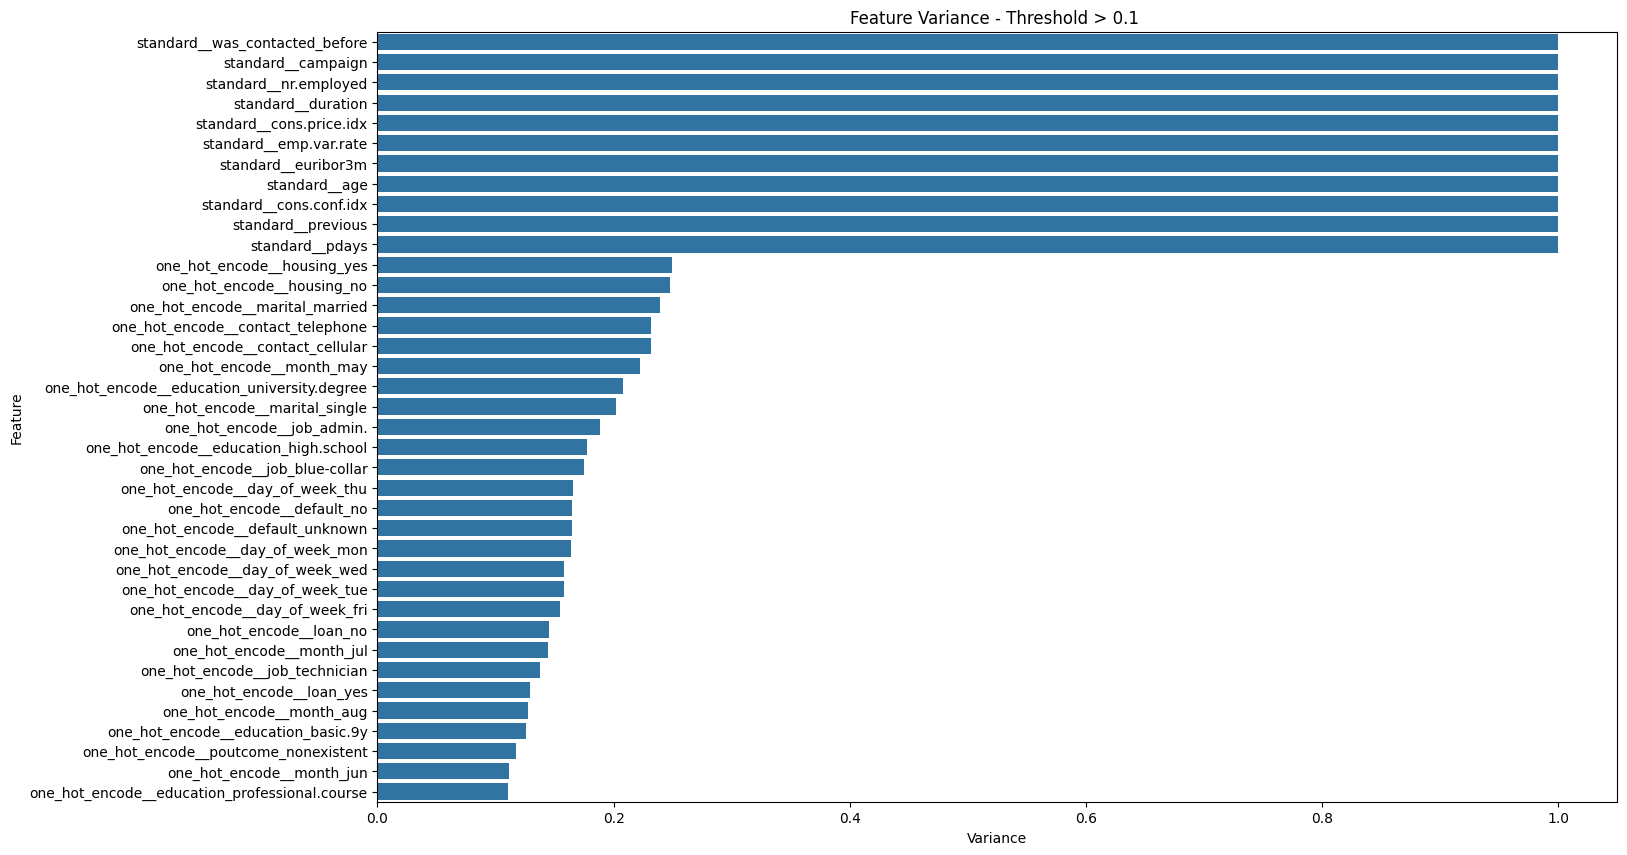

In [94]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.2)
X_train_vt = vt.fit_transform(X_train_encoded)
X_test_vt = vt.transform(X_test_encoded)

lr = LogisticRegression(C=np.inf, max_iter=5000, solver='saga', class_weight='balanced', random_state=9) # without regularization
lr.fit(X_train_vt, y_train)

print(f"Variance Threshold - > Kept features: {X_train_vt.shape[1]}")
#print(classification_report(y_test, lr.predict(X_test_vt)))

df = (pd.DataFrame(np.column_stack([preprocessor_fs.get_feature_names_out(), vt.variances_]), 
              columns=["Feature", "Variance"])).sort_values(by="Variance", ascending=False).reset_index().drop("index", axis=1)

# print(f"Features with variance > 0.2")
features_vt = df[df["Variance"] > 0.1]
print(f"count: {len(features_vt["Feature"].to_list())}, {extract_feature_names(features_vt["Feature"].to_list())}")

plt.figure(figsize=(16, 10))
sns.barplot(x=features_vt["Variance"], y = features_vt["Feature"])
plt.title("Feature Variance - Threshold > 0.1 ")

## Embedded method - Lasso

L1 logistic regression non-zero features count: 27
L1 logistic regression high importance features count: 15 : {'contact', 'euribor3m', 'emp.var.rate', 'pdays', 'default', 'job', 'nr.employed', 'duration', 'poutcome', 'cons.conf.idx', 'cons.price.idx', 'month', 'campaign', 'education', 'day'}


Text(0.5, 1.0, 'L1 regularization Feature importance')

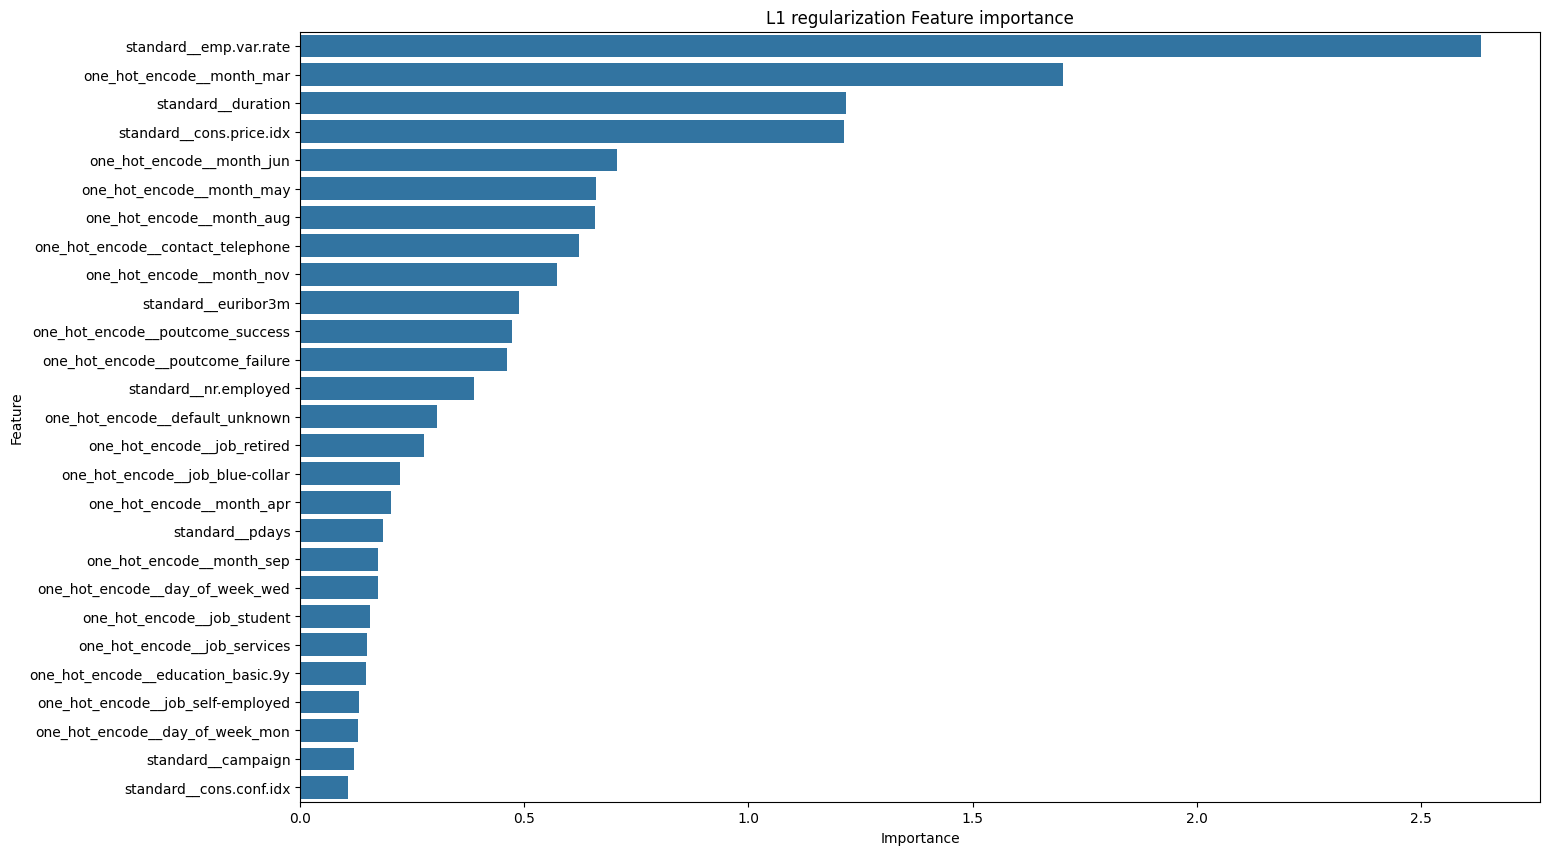

In [95]:

lr_l1 = LogisticRegression(l1_ratio=1, max_iter=5000, solver='saga', random_state=42)
lr_l1.fit(X_train_encoded, y_train)

importance = (pd.DataFrame(np.column_stack([preprocessor_fs.get_feature_names_out(), abs(lr_l1.coef_.flatten())]), 
              columns=["Feature", "Importance"])).sort_values(by="Importance", ascending=False)

high_importance = importance[(importance["Importance"] > 0.1)].reset_index(drop=True).sort_values(by="Importance", ascending=False)

print(f"L1 logistic regression non-zero features count: {high_importance.shape[0]}")
final_features = extract_feature_names(high_importance["Feature"].to_list()) #set([col.split("__")[1].split("_")[0] for col in high_importance["Feature"].to_list()])
print(f"L1 logistic regression high importance features count: {len(final_features)} : {final_features}")

plt.figure(figsize=(16, 10))
sns.barplot(x=high_importance["Importance"], y = high_importance["Feature"])
plt.title("L1 regularization Feature importance")

## F-test

/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


High Variance feature count: 17, Features: {'contact', 'loan', 'marital', 'euribor3m', 'pdays', 'emp.var.rate', 'default', 'job', 'was', 'nr.employed', 'duration', 'poutcome', 'housing', 'cons.price.idx', 'month', 'education', 'day'}


/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Text(0.5, 1.0, 'F-test Feature Importance')

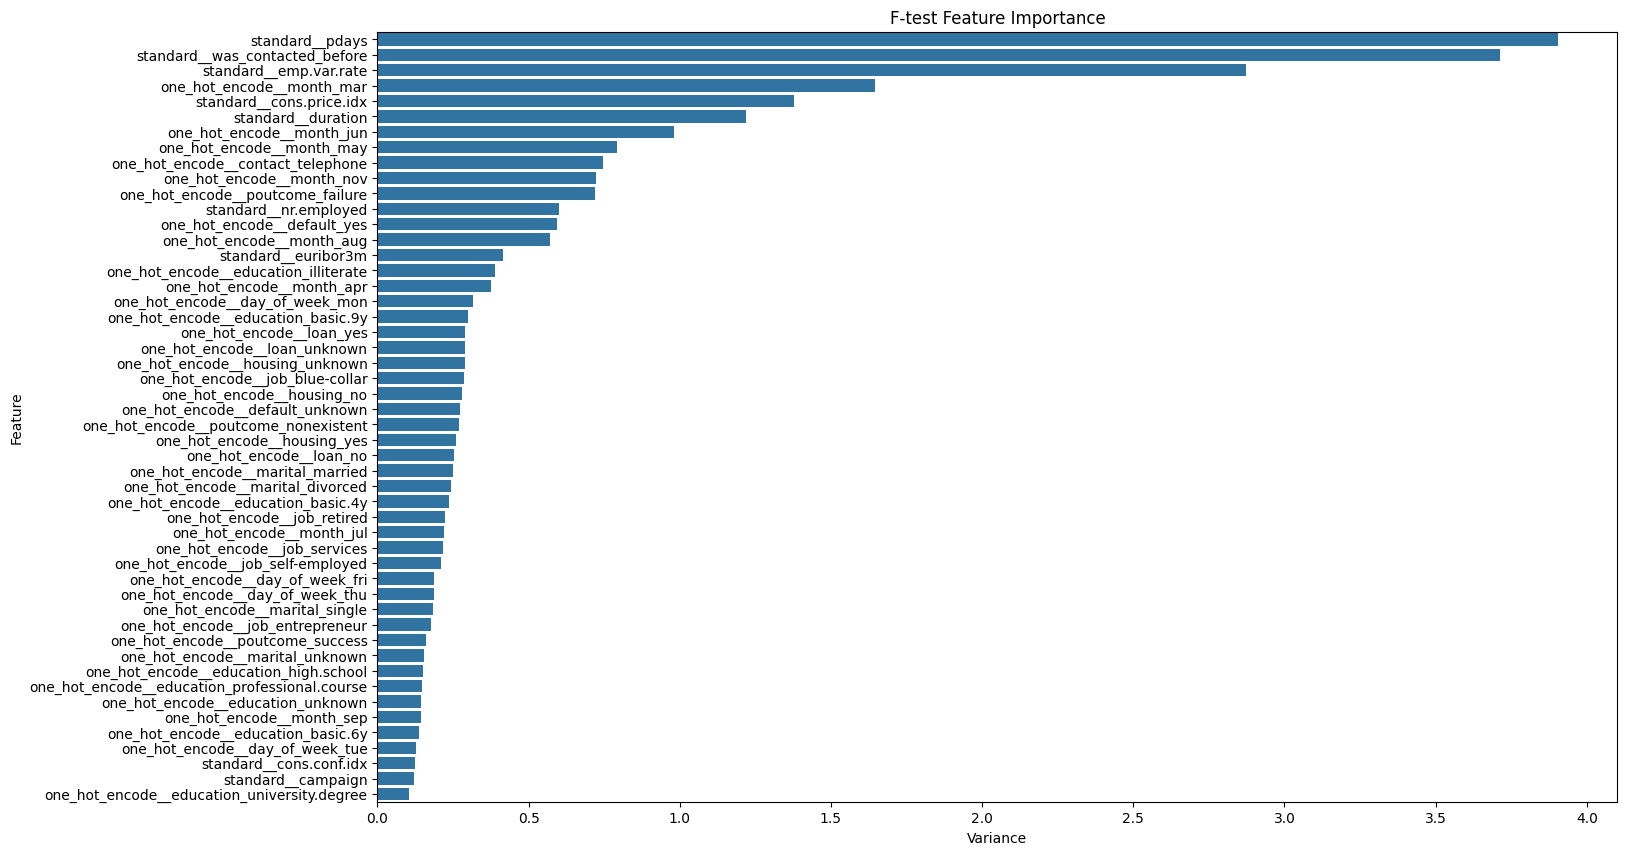

In [96]:
skb_f = SelectKBest(score_func=f_classif, k="all")

X_train_f = skb_f.fit_transform(X_train_encoded, y_train)
skb_lr = LogisticRegression(C=np.inf, max_iter=5000, solver='saga', random_state=9) # unregularized
skb_lr.fit(X_train_f, y_train)

variance_df = (pd.DataFrame(np.column_stack([preprocessor_fs.get_feature_names_out(), abs(skb_lr.coef_.flatten())]), 
              columns=["Feature", "Variance"])).sort_values(by="Variance", ascending=False)

features = extract_feature_names(variance_df[variance_df["Variance"] > 0.2]["Feature"])

print(f"High Variance feature count: {len(features)}, Features: {features}")
high_variance_df= variance_df[variance_df["Variance"] > 0.1]

plt.figure(figsize=(16, 10))
sns.barplot(x=high_variance_df["Variance"], y = high_variance_df["Feature"])
plt.title("F-test Feature Importance")
# skb_features_mask = skb_f.get_support()
# preprocessor_feature_names = preprocessor_fs.get_feature_names_out()
# skb_fatures = preprocessor_feature_names[skb_features_mask]
# print(f"F-test selected features: count: {len(extract_feature_names(skb_fatures))}: {extract_feature_names(skb_fatures)}")


Note:
- Dataset is highly imbalance
- Though "duration" is highly correlated with target, but we would not consider it as independent variable as this is not know when predicting
- EDA suggest that target does not depend on housing and loan

In [97]:
bank_df['age-group'] = pd.cut(bank_df['age'], bins=[0,30,50,100], labels=["young","mid","senior"])


# Preprocessing and baseline models

In [98]:
numeric_cols1 =['campaign', 'previous', 'nr.employed', 'cons.price.idx'] # 'age', 'duration', 'pdays', "month_sin", "month_cos", "day_sin", "day_cos"] # symmetric
numeric_cols2 = ['emp.var.rate', 'cons.conf.idx', 'euribor3m' ] # skewed 'pdays',

cat_mode_impute_cols = ['job', 'marital', 'education'] #'housing', 'loan',
category_cols =  ['default', 'contact',  'poutcome', 'month' , 'day_of_week', 'age-group'] 
passthrough_cols = ['was_contacted_before']

all_features = numeric_cols1 + numeric_cols2 + cat_mode_impute_cols + category_cols + passthrough_cols
X_bank = bank_df[all_features]
y_bank = bank_df["y"]

X_train_bank, X_test_bank, y_train_bank, y_test_bank = train_test_split(X_bank, y_bank, test_size=0.2, stratify=y, random_state=9)
print(X_train_bank.shape, X_test_bank.shape, y_train_bank.shape, y_test_bank.shape)

def replace_unknown(X):
    return X.replace('unknown', np.nan)

category_mode_pipeline = Pipeline(
    steps=[("replace_unknown", FunctionTransformer(replace_unknown)),
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))]
)

preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), numeric_cols1),
    ('robust_scalar', RobustScaler(), numeric_cols2),
    ('mode_one_hot', category_mode_pipeline, cat_mode_impute_cols),
    ("one_hot", OneHotEncoder(handle_unknown='ignore'), category_cols),
    ("pass", 'passthrough', passthrough_cols)
])

(32940, 17) (8236, 17) (32940,) (8236,)


## Baseline models without any feature extraction/ selection

As each marketing call is costly, so we want to check 2 metrics:
1. F1 score - balanced precision - recall
2. F-beta score (precision oriented)

In [99]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, results, model_type):
     pipeline.fit(X_tr, y_tr)

     y_pred_proba_train = pipeline.predict_proba(X_tr)[:,1]
     y_pred_proba_test = pipeline.predict_proba(X_te)[:,1]

     
     thresholds = np.arange(0.1, 0.9, 0.01)

     f1_scores=[]
     for th in thresholds:
          y_pred_test = (y_pred_proba_test > th).astype('int')
          f1_scores.append(f1_score(y_te, y_pred_test))

     
     max_f1_score = max(f1_scores)
     threshold_at_max = thresholds[np.argmax(f1_scores)]

     #print(max_f1_score, threshold_at_max)


     y_pred_train = (y_pred_proba_train > threshold_at_max).astype('int')
     y_pred_test = (y_pred_proba_test > threshold_at_max).astype('int')
     
     # print(pipeline.predict_proba(X_te)[:10,:])
     # print(y_te.iloc[:10])

     cv_score = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='roc_auc')

     train_accuracy = accuracy_score(y_tr, y_pred_train) #pipeline.score(X_tr, y_tr)
     test_accuracy = accuracy_score(y_te, y_pred_test) # pipeline.score(X_te, y_te)
     
     train_roc_auc = roc_auc_score(y_tr, y_pred_proba_train)
     test_roc_auc = roc_auc_score(y_te, y_pred_proba_test)

     test_precision = precision_score(y_te, y_pred_test)
     test_recall = recall_score(y_te, y_pred_test)

     #f_beta at 0.5
     f_beta = (1+ 0.5 ** 2)*((test_precision * test_recall)/ ((0.5**2 * test_precision) + test_recall))

     results.append({
          "Type": model_type,
          'Model': name,
          'Train Accuracy': train_accuracy,
          'Test Accuracy': test_accuracy,
          'Mean CV Score - roc-auc': f"{cv_score.mean():.3f}",
          'Train ROC-AUC': train_roc_auc,
          'Test ROC-AUC': test_roc_auc,
          # 'Train Precision': train_precision,
          # 'Test Precision': test_precision,
          'Train PR-AUC': average_precision_score(y_tr, y_pred_proba_train),
          'Test PR-AUC': average_precision_score(y_te, y_pred_proba_test),
          'Test F1-score': max_f1_score,
          'Threshold': threshold_at_max,
          'Test F-0.5 score': f_beta
          }
     )
     #print(classification_report(y_te, y_pred_test))
     return pipeline 

In [100]:

def run_model(preprocessor, X_train, y_train, X_test, y_test, model_type):
    
    results = []
    fitted_pipeline = {}
    baseline_models = {
        # 'Logistic Regression - ' + model_type: LogisticRegression(C=np.inf, max_iter=5000, solver='saga', random_state=9), # unregularized
        # 'L1 regularization - '+ model_type: LogisticRegression(l1_ratio=1, max_iter=5000, solver='saga', random_state=9),
        'Logistic Regression - Balanced - ' + model_type: LogisticRegression(C=np.inf, max_iter=5000, solver='saga', class_weight='balanced', random_state=9),
        'Elasticnet regularization - Balanced - ' + model_type: LogisticRegression(class_weight='balanced', l1_ratio=0.5, C=4, max_iter=5000, solver='saga', random_state=9),
        'Decision Tree - ' + model_type: DecisionTreeClassifier(min_samples_split=10, random_state=9),
        'KNN - ' + model_type: KNeighborsClassifier(n_neighbors=9),
        'Decision Tree - Balanced - ' + model_type: DecisionTreeClassifier(class_weight='balanced', min_samples_split=10, random_state=9),
    }

    for name, model in baseline_models.items():
        pipe = Pipeline([('pre', preprocessor), ('model', model)])
        fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results, model_type)

    return (pd.DataFrame(results), fitted_pipeline)


In [101]:
results_df_baseline, fitted_pipeline_baseline = run_model(preprocessor, X_train_bank, y_train_bank, X_test_bank, y_test_bank, "baseline")
results_df_baseline

/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScienc

,Type,Model,Train Accuracy,Test Accuracy,Mean CV Score - roc-auc,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC,Test F1-score,Threshold,Test F-0.5 score
0,baseline,Logistic Regression - Balanced - baseline,0.862690,0.869840,0.789,0.794050,0.803404,0.448152,0.468303,0.510949,0.64,0.467914
1,baseline,Elasticnet regularization - Balanced - baseline,0.862629,0.869718,0.789,0.794046,0.803405,0.448252,0.468480,0.510269,0.64,0.467391
2,baseline,Decision Tree - baseline,0.931755,0.862797,0.677,0.966239,0.707515,0.796415,0.293880,0.395722,0.34,0.393952
3,baseline,KNN - baseline,0.891925,0.876153,0.745,0.895844,0.756949,0.516697,0.382484,0.471503,0.23,0.460900
4,baseline,Decision Tree - Balanced - baseline,0.931208,0.862555,0.666,0.967006,0.688229,0.799033,0.297758,0.388108,0.83,0.388865


In [102]:
# check cost curve

y_pred_proba_test = fitted_pipeline_baseline["Elasticnet regularization - Balanced - baseline"].predict_proba(X_test_bank)
baseline_log_loss = log_loss(y_test_bank, y_pred_proba_test)
print(f"Elasticnet regularization - Balanced - baseline Log Loss: {baseline_log_loss}")

fitted_pipeline_baseline["Elasticnet regularization - Balanced - baseline"][1].n_iter_

Elasticnet regularization - Balanced - baseline Log Loss: 0.5124886343163314


array([248], dtype=int32)

### Handle Outliers

In [103]:
def handle_outliers(col):
    q1, q3 = col.quantile([0.25, 0.75])
    iqr = q3-q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return col.clip(lower, upper)


bank_df_clipped= bank_df[numeric_cols1 + numeric_cols2 + cat_mode_impute_cols + category_cols + passthrough_cols].copy()
outlier_df = (bank_df_clipped[numeric_cols1+numeric_cols2].apply(count_outliers)).reset_index().rename(columns={"index": "Feature", 0: "Percentage"})

high_outliers = outlier_df[outlier_df["Percentage"] > 0]["Feature"].to_list()
bank_df_clipped[high_outliers] = bank_df_clipped[high_outliers].apply(handle_outliers)
high_outliers

['campaign', 'previous', 'cons.conf.idx']

In [104]:
X_bank_clipped = bank_df_clipped
y_bank_clipped = bank_df["y"]

X_train_bank_clipped, X_test_bank_clipped, y_train_bank_clipped, y_test_bank_clipped = train_test_split(X_bank_clipped, y, test_size=0.2, stratify=y, random_state=9)
print(X_train_bank_clipped.shape, X_test_bank_clipped.shape, y_train_bank_clipped.shape, y_test_bank_clipped.shape)

preprocessor_outlier = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), numeric_cols1+numeric_cols2),
    ('mode_one_hot', category_mode_pipeline, cat_mode_impute_cols),
    ("one_hot", OneHotEncoder(handle_unknown='ignore'), category_cols),
    ("pass", 'passthrough', passthrough_cols)
])


(32940, 17) (8236, 17) (32940,) (8236,)


In [105]:
results_df_outliers, fitted_pipeline_outliers = run_model(preprocessor_outlier, X_train_bank_clipped, y_train_bank_clipped, 
                                                 X_test_bank_clipped, y_test_bank_clipped, "baseline - Outliers Winsorization")
results_df_outliers

/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScienc

,Type,Model,Train Accuracy,Test Accuracy,Mean CV Score - roc-auc,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC,Test F1-score,Threshold,Test F-0.5 score
0,baseline - Outliers Winsorization,Logistic Regression - Balanced - baseline - Ou...,0.864663,0.871782,0.788,0.793116,0.803003,0.448583,0.469002,0.510658,0.65,0.471101
1,baseline - Outliers Winsorization,Elasticnet regularization - Balanced - baselin...,0.864663,0.871904,0.788,0.793115,0.803010,0.448596,0.468790,0.511348,0.65,0.471634
2,baseline - Outliers Winsorization,Decision Tree - baseline - Outliers Winsorization,0.932939,0.871297,0.674,0.964337,0.696807,0.788852,0.300506,0.401806,0.41,0.413569
3,baseline - Outliers Winsorization,KNN - baseline - Outliers Winsorization,0.891500,0.877125,0.747,0.896871,0.762545,0.519951,0.394029,0.474559,0.23,0.464431
4,baseline - Outliers Winsorization,Decision Tree - Balanced - baseline - Outliers...,0.932665,0.866804,0.665,0.966543,0.681276,0.797653,0.295286,0.386122,0.85,0.395280


              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7308
           1       0.45      0.59      0.51       928

    accuracy                           0.87      8236
   macro avg       0.70      0.75      0.72      8236
weighted avg       0.89      0.87      0.88      8236



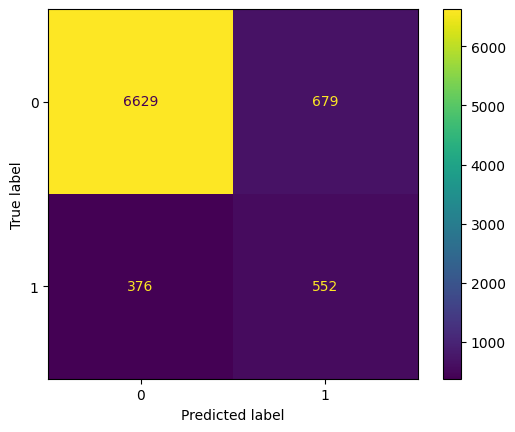

In [106]:
y_pred_proba_test = fitted_pipeline_outliers["Elasticnet regularization - Balanced - baseline - Outliers Winsorization"].predict_proba(X_test_bank_clipped)[:,1]
y_pred_test = (y_pred_proba_test > 0.65).astype('int')

cm = confusion_matrix(y_test_bank, y_pred_test)
ConfusionMatrixDisplay(cm).plot()

print(classification_report(y_test_bank, y_pred_test))

# Advance Models & Feature Engineering

## Advance Models

In [107]:
#numeric_cols1 =['age', 'campaign', 'previous', 'nr.employed', 'cons.price.idx'] # 'duration', 'pdays', "month_sin", "month_cos", "day_sin", "day_cos"] # symmetric
#numeric_cols2 = ['emp.var.rate', 'cons.conf.idx', 'euribor3m' ] # skewed 'pdays',

cat_mode_impute_cols = ['job', 'marital', 'education'] #'housing', 'loan',
category_cols =  ['default', 'contact',  'poutcome' , 'month' , 'day_of_week', 'age-group'] #'month' , 'day_of_week'
passthrough_cols = ['campaign', 'previous', 'nr.employed', 'cons.price.idx', 'emp.var.rate', 'cons.conf.idx', 'euribor3m', "was_contacted_before" ] #'age', 

category_mode_pipeline = Pipeline(
    steps=[("replace_unknown", FunctionTransformer(replace_unknown)),
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))]
)

preprocessor_advanced = ColumnTransformer(transformers=[
    #('standard', StandardScaler(), numeric_cols1),
    #('min_max_scalar', MinMaxScaler(), numeric_cols2),
    ('mode_one_hot', category_mode_pipeline, cat_mode_impute_cols),
    ("one_hot", OneHotEncoder(handle_unknown='ignore'), category_cols),
    ("pass", 'passthrough', passthrough_cols)
])

In [108]:
def run_advance_models(preprocessor, X_train, y_train, X_test, y_test, model_type):
    results = []
    fitted_pipeline = {}

    ratio = (y_train == 0).sum() / (y_train == 1).sum()
    #print(ratio)
    advance_models = {
        'Random Forest - ' + model_type: RandomForestClassifier(n_estimators=100, min_samples_split=10, oob_score=True, random_state=9),
        'Random Forest - Balanced - ' + model_type: RandomForestClassifier(n_estimators=100, min_samples_split=10, class_weight='balanced', oob_score=True, random_state=9),
        'Adaboost - ' + model_type: AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=9),
        'Adaboost - Balanced - ' + model_type: AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'), n_estimators=100,  random_state=9),
        'XGBoost - ' + model_type: XGBClassifier(eval_metric='auc', scale_pos_weight=ratio, n_estimators=500, learning_rate=0.03, max_depth=5, random_state=42),
        #'LightGBM - ' + model_type:lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=9)
    }

    fitted_pipeline = {}
    for name, model in advance_models.items():
        pipe = Pipeline([('pre', preprocessor), ('model', model)])
        fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results, model_type)

    return (pd.DataFrame(results), fitted_pipeline)



In [109]:
results_df_advanced, fitted_pipeline_advanced = run_advance_models(preprocessor_advanced, X_train_bank, y_train_bank, X_test_bank, y_test_bank, "Advanced")
results_df_advanced

,Type,Model,Train Accuracy,Test Accuracy,Mean CV Score - roc-auc,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC,Test F1-score,Threshold,Test F-0.5 score
0,Advanced,Random Forest - Advanced,0.919915,0.886717,0.778,0.960118,0.806804,0.769725,0.484944,0.519320,0.28,0.506024
1,Advanced,Random Forest - Balanced - Advanced,0.915726,0.875182,0.774,0.966465,0.803816,0.781658,0.471854,0.499025,0.50,0.471976
2,Advanced,Adaboost - Advanced,0.868033,0.875182,0.782,0.787618,0.799353,0.438232,0.458632,0.508134,0.39,0.476148
3,Advanced,Adaboost - Balanced - Advanced,0.872890,0.878825,0.699,0.698530,0.707350,0.267807,0.283412,0.474737,0.12,0.468231
4,Advanced,XGBoost - Advanced,0.878081,0.878096,0.792,0.852696,0.817471,0.556452,0.495593,0.525520,0.62,0.489437


In [110]:
# with outliers handling
results_df_advanced_outliers, fitted_pipeline_advanced_outliers = run_advance_models(preprocessor_advanced, X_train_bank_clipped, 
                                                                y_train_bank_clipped, X_test_bank_clipped, y_test_bank_clipped, 
                                                                "Advanced - Outliers Winsorization")
results_df_advanced_outliers

,Type,Model,Train Accuracy,Test Accuracy,Mean CV Score - roc-auc,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC,Test F1-score,Threshold,Test F-0.5 score
0,Advanced - Outliers Winsorization,Random Forest - Advanced - Outliers Winsorization,0.919277,0.887203,0.778,0.959746,0.806831,0.767119,0.483607,0.519400,0.28,0.507276
1,Advanced - Outliers Winsorization,Random Forest - Balanced - Advanced - Outliers...,0.923619,0.889024,0.775,0.965499,0.804427,0.777925,0.472703,0.498904,0.57,0.504211
2,Advanced - Outliers Winsorization,Adaboost - Advanced - Outliers Winsorization,0.867122,0.874696,0.784,0.787461,0.798512,0.437058,0.456892,0.507163,0.38,0.474785
3,Advanced - Outliers Winsorization,Adaboost - Balanced - Advanced - Outliers Wins...,0.872890,0.878825,0.699,0.698530,0.707350,0.267807,0.283412,0.474737,0.12,0.468231
4,Advanced - Outliers Winsorization,XGBoost - Advanced - Outliers Winsorization,0.886066,0.883317,0.790,0.855704,0.817264,0.564349,0.498376,0.524963,0.65,0.500188


### Best Model

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7308
           1       0.47      0.60      0.53       928

    accuracy                           0.88      8236
   macro avg       0.71      0.76      0.73      8236
weighted avg       0.89      0.88      0.88      8236



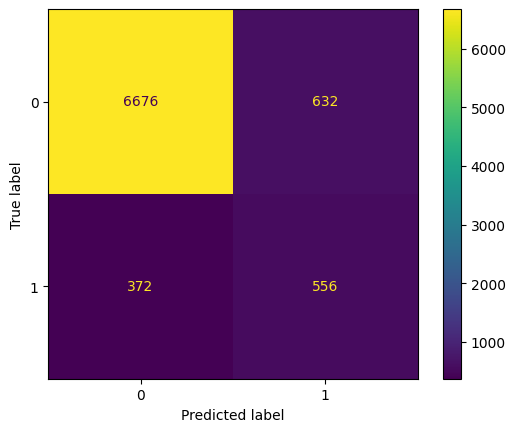

In [111]:
y_pred_proba_test = fitted_pipeline_advanced["XGBoost - Advanced"].predict_proba(X_test_bank[all_features])[:,1]
best_threshold = results_df_advanced[results_df_advanced["Model"] == "XGBoost - Advanced"]["Threshold"].values

y_pred_test = (y_pred_proba_test > best_threshold).astype('int')

cm = confusion_matrix(y_test_bank, y_pred_test)
ConfusionMatrixDisplay(cm).plot()

print(classification_report(y_test_bank, y_pred_test))

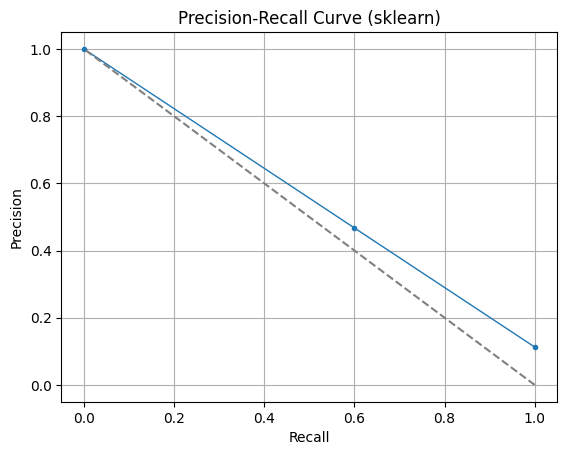

In [112]:
prec, rec, pr_thre = precision_recall_curve(y_test_bank, y_pred_test)

plt.plot(rec, prec, marker='.', linewidth=1)
plt.plot([1,0],[0,1], linestyle='--', color='gray', label='Random')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (sklearn)")
plt.grid(True)
plt.show()

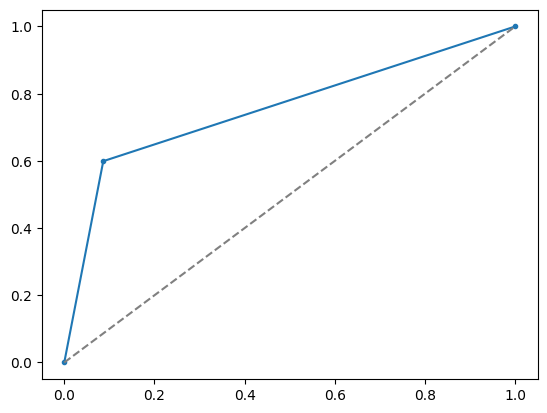

In [113]:
from sklearn.metrics import roc_curve

fpr_arr, tpr_arr, roc_thresholds = roc_curve(y_test_bank, y_pred_test)

plt.plot(fpr_arr, tpr_arr, marker='.', label=f"ROC (AUC={roc_auc_score(y_test_bank, y_pred_test):.4f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random')

## SMOTE

In [114]:
from imblearn.over_sampling import SMOTENC


numeric_cols1 =['campaign', 'previous', 'nr.employed', 'cons.price.idx'] # ''age',  duration', 'pdays', "month_sin", "month_cos", "day_sin", "day_cos"] # symmetric
numeric_cols2 = ['emp.var.rate', 'cons.conf.idx', 'euribor3m' ] # skewed 'pdays',

cat_mode_impute_cols = ['job', 'marital', 'education'] #'housing', 'loan',
category_cols =  ['default', 'contact',  'poutcome', 'month' , 'day_of_week' ,'age-group'] #'month' , 'day_of_week'
passthrough_cols = ['was_contacted_before']

all_features = numeric_cols1+numeric_cols2+cat_mode_impute_cols+category_cols+passthrough_cols

category_mode_pipeline = Pipeline(
    steps=[("replace_unknown", FunctionTransformer(lambda X: X.replace('unknown', np.nan))),
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore') )]
)

preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), numeric_cols1),
    ('robust-scalar', RobustScaler(), numeric_cols2),
    ('mode_one_hot', category_mode_pipeline, cat_mode_impute_cols),
    ("one_hot", OneHotEncoder(handle_unknown='ignore'), category_cols),
    ("pass", 'passthrough', passthrough_cols)
])


#SmoteNC
smote_nc = SMOTENC(categorical_features=cat_mode_impute_cols+category_cols, random_state=42)

X_train_res, y_train_res = smote_nc.fit_resample(X_train_bank, y_train_bank)


print('Resampled class distribution (SMOTE):', np.bincount(y_train_res))

Resampled class distribution (SMOTE): [29229 29229]


In [115]:

def run_model_smote(preprocessor, X_train, y_train, X_test, y_test, model_type):
    
    results = []
    fitted_pipeline = {}

    baseline_models = {
        'Logistic Regression - ' + model_type: LogisticRegression(C=np.inf,  max_iter=5000, solver='saga', random_state=9), # unregularized
        'Elasticnet regularization - ' + model_type: LogisticRegression(l1_ratio=0.5, C=4, max_iter=5000, solver='saga', random_state=9),
        'Decision Tree - ' + model_type: DecisionTreeClassifier(min_samples_split=10, random_state=9)
    }

    for name, model in baseline_models.items():
        pipe = Pipeline([('pre', preprocessor), ('model', model)])
        fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results, model_type)

    return (pd.DataFrame(results), fitted_pipeline)

In [116]:
results_baseline_smote, fitted_models_baseline_smote = run_model_smote(preprocessor, X_train_res, y_train_res, X_test_bank, y_test_bank, "Baseline - SMOTE")
results_baseline_smote

/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/DataScienc

,Type,Model,Train Accuracy,Test Accuracy,Mean CV Score - roc-auc,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC,Test F1-score,Threshold,Test F-0.5 score
0,Baseline - SMOTE,Logistic Regression - Baseline - SMOTE,0.740497,0.880403,0.821,0.823107,0.784267,0.840378,0.435090,0.490429,0.67,0.478981
1,Baseline - SMOTE,Elasticnet regularization - Baseline - SMOTE,0.743200,0.876396,0.821,0.823102,0.784420,0.840382,0.434928,0.490490,0.64,0.470430
2,Baseline - SMOTE,Decision Tree - Baseline - SMOTE,0.936091,0.814594,0.922,0.989634,0.707783,0.989386,0.277338,0.375971,0.39,0.328384


In [117]:
def run_advance_models_smote(preprocessor, X_train, y_train, X_test, y_test, model_type):
    results = []
    fitted_pipeline = {}

    advance_models = {
        'Random Forest - ' + model_type: RandomForestClassifier(n_estimators=100, oob_score=True, random_state=9),
        'Adaboost - ' + model_type: AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=9),
        'XGBoost - ' + model_type: XGBClassifier(eval_metric='auc', n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
    }

    fitted_pipeline = {}
    for name, model in advance_models.items():
        pipe = Pipeline([('pre', preprocessor), ('model', model)])
        fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results, model_type)

    return (pd.DataFrame(results), fitted_pipeline)

In [118]:
results_df_advanced_smote, fitted_pipeline_advanced_smote = run_advance_models_smote(preprocessor_advanced, X_train_res, y_train_res, X_test_bank, y_test_bank, "Advanced - Smote")
results_df_advanced_smote

,Type,Model,Train Accuracy,Test Accuracy,Mean CV Score - roc-auc,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC,Test F1-score,Threshold,Test F-0.5 score
0,Advanced - Smote,Random Forest - Advanced - Smote,0.965958,0.821880,0.958,0.995973,0.775136,0.995880,0.335389,0.414371,0.38,0.358624
1,Advanced - Smote,Adaboost - Advanced - Smote,0.738804,0.865347,0.812,0.813458,0.795739,0.831267,0.447395,0.493376,0.53,0.452110
2,Advanced - Smote,XGBoost - Advanced - Smote,0.800951,0.884046,0.894,0.904042,0.788989,0.909609,0.457974,0.494976,0.62,0.489540


In [119]:
y_pred = fitted_pipeline_advanced_smote["XGBoost - Advanced - Smote"].predict(X_test_bank)
print(classification_report(y_test_bank, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      7308
           1       0.39      0.59      0.47       928

    accuracy                           0.85      8236
   macro avg       0.67      0.73      0.69      8236
weighted avg       0.88      0.85      0.86      8236



# HyperParameter Tuning

In [120]:
from sklearn.model_selection import GridSearchCV

#n_estimators=300, learning_rate=0.05, max_depth=4, 
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500, 700],
    'max_depth': [4, 5, 10],
    'learning_rate': [0.01,0.05, 0.1]
}

ratio = (y_train_bank == 0).sum() / (y_train_bank == 1).sum()

pipe = Pipeline([
    ("pre", preprocessor_advanced),
    ("model", XGBClassifier(eval_metric='auc', scale_pos_weight=ratio, random_state=42))
])
grid_search = GridSearchCV(
    pipe,
    param_grid={f'model__{k}': v for k, v in param_grid.items()},
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)


# X_train_bank_encoded = preprocessor.fit_transform(X_train_bank)
# X_test_bank_encoded= preprocessor.transform(X_test_bank)

grid_search.fit(X_train_bank, y_train_bank)
print("Best parameters:", grid_search.best_params_)
print(f"Best CV avaerage precision: {grid_search.best_score_:.4f}")


Best parameters: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 500}
Best CV avaerage precision: 0.4633


In [121]:
#X_test_bank2= preprocessor.transform(X_test_bank[cols])

best_xgboost = grid_search.best_estimator_

y_pred_proba = best_xgboost.predict_proba(X_test_bank)[:,1]


thresholds = np.arange(0.1, 0.9, 0.01)

f1_scores=[]
for th in thresholds:
    y_pred_test = (y_pred_proba > th).astype('int')
    #print(y_pred_test)
    f1_scores.append(f1_score(y_test_bank, y_pred_test))


max_f1_score = max(f1_scores)
threshold_at_max = thresholds[np.argmax(f1_scores)]
y_pred_test = (y_pred_proba > threshold_at_max).astype('int')

print(f"Max F1 score: {round(max_f1_score, 3)} at threshold {round(threshold_at_max, 3)}")
print(f"ROC-AUC: {roc_auc_score(y_test_bank, y_pred_proba)}")
print(f"PR-AUC: {average_precision_score(y_test_bank, y_pred_proba)}")



Max F1 score: 0.524 at threshold 0.62
ROC-AUC: 0.8191043442000263
PR-AUC: 0.4933377172347196


In [122]:

from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'n_estimators': list(range(100, 500, 50)), #randint(100, 500),
    'max_depth': [None] + list(range(4, 10)),
    'learning_rate': np.random.uniform(0.01, 0.1, 10), #[0.01,0.05, 0.1],
    'min_child_weight': [3, 5, 7],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5]
}


pipe = Pipeline([
    ("pre", preprocessor_advanced),
    ("model", XGBClassifier(eval_metric='auc', scale_pos_weight=ratio, random_state=42))
])

random_search = RandomizedSearchCV(
    pipe,
    param_distributions={f'model__{k}': v for k, v in param_dist.items()},
    n_iter=20,
    cv=5,
    scoring='average_precision',
    random_state=123,
    n_jobs=-1
)

random_search.fit(X_train_bank, y_train_bank)
print("Best parameters (Random Search):", random_search.best_params_)
print(f"Best CV average_precision: {random_search.best_score_:.4f}")


Best parameters (Random Search): {'model__subsample': 0.9, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': np.float64(0.05272972101254477), 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}
Best CV average_precision: 0.4672


In [123]:
#X_test_bank2= preprocessor.transform(X_test_bank)
best_xgboost = random_search.best_estimator_

y_pred_proba = best_xgboost.predict_proba(X_test_bank)[:,1]

thresholds = np.arange(0.1, 0.9, 0.01)

f1_scores=[]
for th in thresholds:
    y_pred_test = (y_pred_proba > th).astype('int')
    f1_scores.append(f1_score(y_test_bank, y_pred_test))


max_f1_score = max(f1_scores)
threshold_at_max = thresholds[np.argmax(f1_scores)]
y_pred_test = (y_pred_proba > threshold_at_max).astype('int')

print(f"Max F1 score: {round(max_f1_score, 4)} at threshold {round(threshold_at_max, 3)}")
print(f"ROC-AUC: {roc_auc_score(y_test_bank, y_pred_proba)}")
print(f"PR-AUC: {average_precision_score(y_test_bank, y_pred_proba)}")

Max F1 score: 0.5186 at threshold 0.6
ROC-AUC: 0.8194805704188135
PR-AUC: 0.49551523137721176


In [124]:
print(classification_report(y_test_bank, y_pred_test))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93      7308
           1       0.45      0.62      0.52       928

    accuracy                           0.87      8236
   macro avg       0.70      0.76      0.72      8236
weighted avg       0.89      0.87      0.88      8236



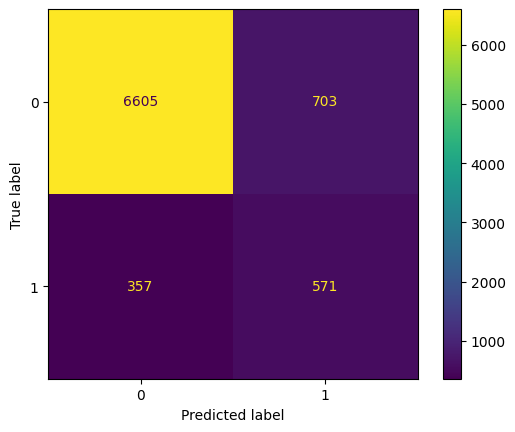

In [125]:
cm = confusion_matrix(y_test_bank, y_pred_test)
ConfusionMatrixDisplay(cm).plot()

# Save Best Model

In [126]:
import joblib

In [127]:
best_xgboost

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mode_one_hot', ...), ('one_hot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [128]:
#best_model = fitted_pipeline_advanced["XGBoost - Advanced"]
joblib.dump(best_xgboost, "models/best_xgboost.joblib")


['models/best_xgboost.joblib']

In [129]:
test_data_df = pd.read_csv("test.csv", sep=";")
test_data_df["was_contacted_before"] = (test_data_df["pdays"] == 999).astype('int')
test_data_df['age-group'] = pd.cut(test_data_df['age'], bins=[0,30,50,100], labels=["young","mid","senior"])

X = test_data_df.drop(columns="y")

In [130]:
loaded_model = joblib.load("models/best_xgboost.joblib")
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mode_one_hot', ...), ('one_hot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [131]:
y_pred_proba1 = loaded_model.predict_proba(X)[:,1]
y_pred1 = (y_pred_proba1 > best_threshold[0]).astype('int')

test_data_df["predicted_y"] = y_pred1
test_data_df



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before,age-group,predicted_y
0,43,services,divorced,professional.course,no,no,no,telephone,may,mon,75,4,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,no,1,mid,0
1,46,blue-collar,married,basic.9y,no,yes,yes,telephone,may,mon,386,2,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,no,1,mid,0
2,30,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,544,3,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,no,1,young,0
3,36,blue-collar,married,basic.6y,no,yes,no,cellular,may,mon,127,2,999,1,failure,-1.8,92.893,-46.2,1.299,5099.1,no,1,mid,0
4,30,admin.,single,university.degree,no,no,no,cellular,may,mon,155,2,999,1,failure,-1.8,92.893,-46.2,1.299,5099.1,no,1,young,0
5,32,entrepreneur,married,basic.9y,no,no,no,cellular,may,mon,184,4,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,no,1,mid,0
6,42,entrepreneur,married,basic.4y,unknown,no,no,cellular,may,mon,120,2,999,1,failure,-1.8,92.893,-46.2,1.299,5099.1,no,1,mid,0
7,56,services,single,basic.4y,unknown,yes,no,cellular,may,mon,480,2,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,no,1,senior,0
8,54,management,married,high.school,unknown,no,no,cellular,may,mon,194,2,999,1,failure,-1.8,92.893,-46.2,1.299,5099.1,no,1,senior,0
9,39,blue-collar,married,basic.6y,unknown,no,no,cellular,may,mon,1232,2,999,0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,yes,1,mid,0
